In [25]:
import sqlite3      # Library for  working with the SQLite database
import pandas as pd
import matplotlib.pyplot as plt

# Create connection to the SQLite database
conn = sqlite3.connect('Chinook_Sqlite.sqlite')

def run_query(query):
    """Function to run the SQL queries and easily return the results as a pandas DataFrame."""
    return pd.read_sql_query(query, conn)   # Tool from pd to process the SQL query and return the results as a DataFrame. Uses the query and "conn", which is basically the database we're working with.

In [26]:
# Gathering what are the tables before starting to query the database.

query_schema = """ SELECT name FROM sqlite_master WHERE type = 'table'; """

run_query(query_schema)

,name
0,Album
1,Artist
2,Customer
3,Employee
4,Genre
5,Invoice
6,InvoiceLine
7,MediaType
8,Playlist
9,PlaylistTrack


In [35]:
# Defining function to plot the results of the queries in a bar chart.

def plot_bar_chart(xdata, ydata, xlabel, ylabel, title):
    """Function to plot the results of the queries in a bar chart."""

    plt.figure(figsize=(8, 4))   # Create a new figure with a specified size.

    plt.bar(xdata, ydata, color='skyblue')  # Create a bar chart with data from the DataFrame.

    # Defining the chart's title and labels.
    plt.title(title, fontsize=14)    # Chart title.
    plt.xlabel(xlabel, fontsize=12)     # X-axis label.
    plt.ylabel(ylabel, fontsize=12)   # Y-axis label.

    plt.xticks(rotation=45)    # Rotate x-axis labels for better readability.


    plt.tight_layout()  # Adjust the layout to prevent overlapping.
    plt.show()      # Display the chart.


,Song,Quantity_Sold
0,The Trooper,5
1,Untitled,4
2,The Number Of The Beast,4
3,Sure Know Something,4
4,Hallowed Be Thy Name,4
5,Eruption,4
6,Where Eagles Dare,3
7,Welcome Home (Sanitarium),3
8,Sweetest Thing,3
9,Surrender,3


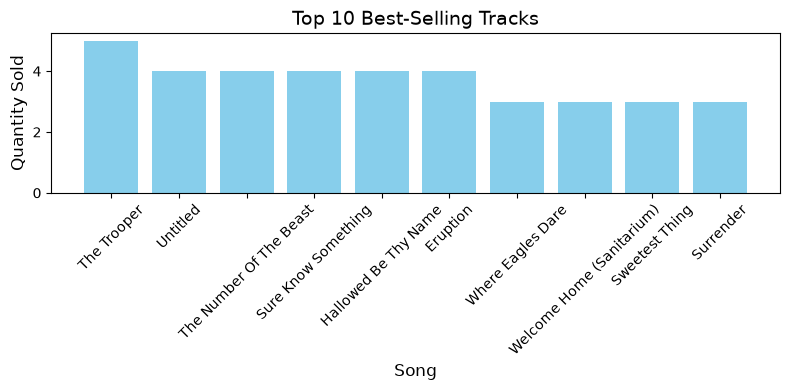

In [34]:
# Which are the 10 best-selling tracks?

query_top_tracks = """
SELECT Name AS Song, SUM(Quantity) AS Quantity_Sold
FROM Track JOIN InvoiceLine
ON InvoiceLine.TrackID = Track.TrackID
GROUP BY Song
ORDER BY Quantity_Sold DESC
LIMIT 10;
"""

top_tracks = run_query(query_top_tracks)
display(top_tracks)
plot_bar_chart(top_tracks['Song'], top_tracks['Quantity_Sold'], 'Song', 'Quantity Sold', 'Top 10 Best-Selling Tracks')

,Country,Total_Revenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48


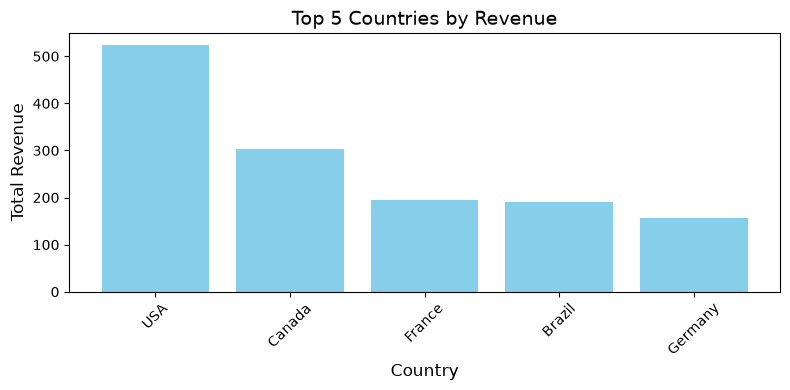

In [36]:
# Which country generates the most revenue?

query_top_countries = """
SELECT BillingCountry AS Country, SUM(Total) AS Total_Revenue
FROM Invoice
GROUP BY Country
ORDER BY Total_Revenue DESC
LIMIT 5;
"""

top_countries = run_query(query_top_countries)
display(top_countries)
plot_bar_chart(top_countries['Country'], top_countries['Total_Revenue'], 'Country', 'Total Revenue', 'Top 5 Countries by Revenue')


,Total_Sales,Employee_Name
0,833.04,Jane Peacock
1,775.40,Margaret Park
2,720.16,Steve Johnson


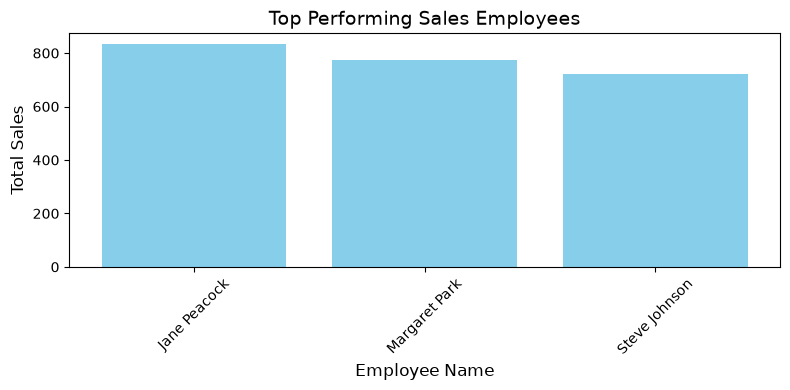

In [37]:
# Who is the top-performing sales employee?

query_top_employees = """
SELECT SUM(i.Total) AS Total_Sales, e.FirstName || ' ' || e.LastName AS Employee_Name
FROM Invoice i
JOIN Customer c ON i.CustomerId = c.CustomerId
JOIN Employee e ON c.SupportRepId = e.EmployeeId
GROUP BY Employee_Name
ORDER BY Total_Sales DESC LIMIT 5;
"""

top_employees = run_query(query_top_employees)
display(top_employees)
plot_bar_chart(top_employees['Employee_Name'], top_employees['Total_Sales'], 'Employee Name', 'Total Sales', 'Top Performing Sales Employees')